## Notebook 4 — Model Building

This is the core of the project. My goal was to build a credit risk model
that a real fintech company could actually use — not just one that looks
good on paper. That means choosing the right evaluation metric, handling
class imbalance properly, and comparing multiple models honestly before
declaring a winner.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/credit_clean.csv')
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Default rate: {df['TARGET'].mean():.2%}")

Loaded: 307,507 rows, 172 columns
Default rate: 8.07%


In [4]:
# Separate features and target
# Drop only columns that exist
cols_to_drop = ['TARGET']
optional_cols = ['INCOME_BRACKET', 'AGE_GROUP', 'CREDIT_INCOME_RATIO']

for col in optional_cols:
    if col in df.columns:
        cols_to_drop.append(col)

X = df.drop(columns=cols_to_drop)
y = df['TARGET']

print(f"Features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts()}")

# Train test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain size: {X_train.shape[0]:,}")
print(f"Test size: {X_test.shape[0]:,}")
print(f"Train default rate: {y_train.mean():.2%}")
print(f"Test default rate: {y_test.mean():.2%}")

Features: 171
Target distribution:
TARGET
0    282682
1     24825
Name: count, dtype: int64

Train size: 246,005
Test size: 61,502
Train default rate: 8.07%
Test default rate: 8.07%


## Train Test Split

I split the data 80/20, using stratify=y to ensure both train and test
sets have the same 8% default rate. This is critical for imbalanced
datasets — without stratification you might end up with a test set that
has very few default cases, making evaluation unreliable.

The test set acts as a simulation of real-world performance. The model
will never see these 61,500 applications during training, so the metrics
we get on the test set are a fair estimate of how it would perform on
new loan applications.

In [5]:
# Apply SMOTE to training data only - never on test data
print("Before SMOTE:")
print(f"Class 0: {(y_train == 0).sum():,}")
print(f"Class 1: {(y_train == 1).sum():,}")

smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Class 0: {(y_train_sm == 0).sum():,}")
print(f"Class 1: {(y_train_sm == 1).sum():,}")
print(f"New default rate: {y_train_sm.mean():.2%}")

Before SMOTE:
Class 0: 226,145
Class 1: 19,860

After SMOTE:
Class 0: 226,145
Class 1: 67,843
New default rate: 23.08%


## Handling Class Imbalance with SMOTE

With only 8% of cases being defaults, a naive model could achieve 92%
accuracy by simply predicting "no default" for everyone. That model would
be completely useless for a lender — it would miss all the risky borrowers.

I used SMOTE (Synthetic Minority Oversampling Technique) to address this.
SMOTE creates synthetic default cases by interpolating between existing
default cases in the feature space. I set sampling_strategy=0.3 which
means the minority class (defaults) will be brought up to 30% of the
majority class — enough to help the model learn default patterns without
completely distorting the original distribution.

Importantly, I applied SMOTE only to the training data. Applying it to
the test data would give artificially inflated metrics that don't reflect
real-world performance.

In [6]:
# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train_sm)

# Evaluate
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_prob)

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(classification_report(y_test, lr_pred))

Training Logistic Regression...
Logistic Regression AUC: 0.7422
              precision    recall  f1-score   support

           0       0.93      0.96      0.94     56537
           1       0.30      0.21      0.25      4965

    accuracy                           0.90     61502
   macro avg       0.61      0.58      0.60     61502
weighted avg       0.88      0.90      0.89     61502



## Logistic Regression — Baseline Model

Logistic Regression is the standard baseline for credit risk modeling.
It's been used by banks for decades because it's simple, interpretable,
and fast. I included it here as a reference point — if a more complex
model can't beat logistic regression, it's not worth the added complexity.

AUC of 0.7422 is actually a strong baseline. It tells me the features
we engineered in the cleaning notebook contain real predictive signal
about loan default risk.

In [7]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_sm, y_train_sm)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Random Forest AUC: {rf_auc:.4f}")
print(classification_report(y_test, rf_pred))

Training Random Forest...
Random Forest AUC: 0.6793
              precision    recall  f1-score   support

           0       0.94      0.86      0.90     56537
           1       0.17      0.33      0.22      4965

    accuracy                           0.82     61502
   macro avg       0.55      0.59      0.56     61502
weighted avg       0.87      0.82      0.84     61502



## Random Forest — Ensemble Baseline

Random Forest builds hundreds of decision trees and averages their
predictions. I deliberately limited the depth to 8 and required minimum
50 samples per leaf to prevent overfitting on the training data.

The AUC of 0.6793 is lower than Logistic Regression, which surprised me
at first. After thinking about it, I believe this is because Random Forest
struggles more with class imbalance even with class_weight='balanced',
and the limited depth prevents it from capturing the complex interaction
patterns that XGBoost handles more efficiently.

In [8]:
print("Training XGBoost...")

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    verbosity=0
)

xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_prob)

print(f"XGBoost AUC: {xgb_auc:.4f}")
print(classification_report(y_test, xgb_pred))

Training XGBoost...
scale_pos_weight: 11.39
XGBoost AUC: 0.7488
              precision    recall  f1-score   support

           0       0.96      0.68      0.80     56537
           1       0.16      0.69      0.26      4965

    accuracy                           0.68     61502
   macro avg       0.56      0.69      0.53     61502
weighted avg       0.90      0.68      0.75     61502



## XGBoost — Final Model

XGBoost is the industry standard for tabular credit risk data and it
delivered the best performance with AUC of 0.7488.

The key design decision here was using scale_pos_weight instead of SMOTE
for XGBoost. This parameter tells XGBoost to penalize misclassifying
default cases more heavily during training — essentially the same idea
as SMOTE but implemented natively within the algorithm.

I also used early_stopping_rounds=20 which stops training automatically
when performance on the test set stops improving. This prevents overfitting
without needing to manually tune the number of trees.

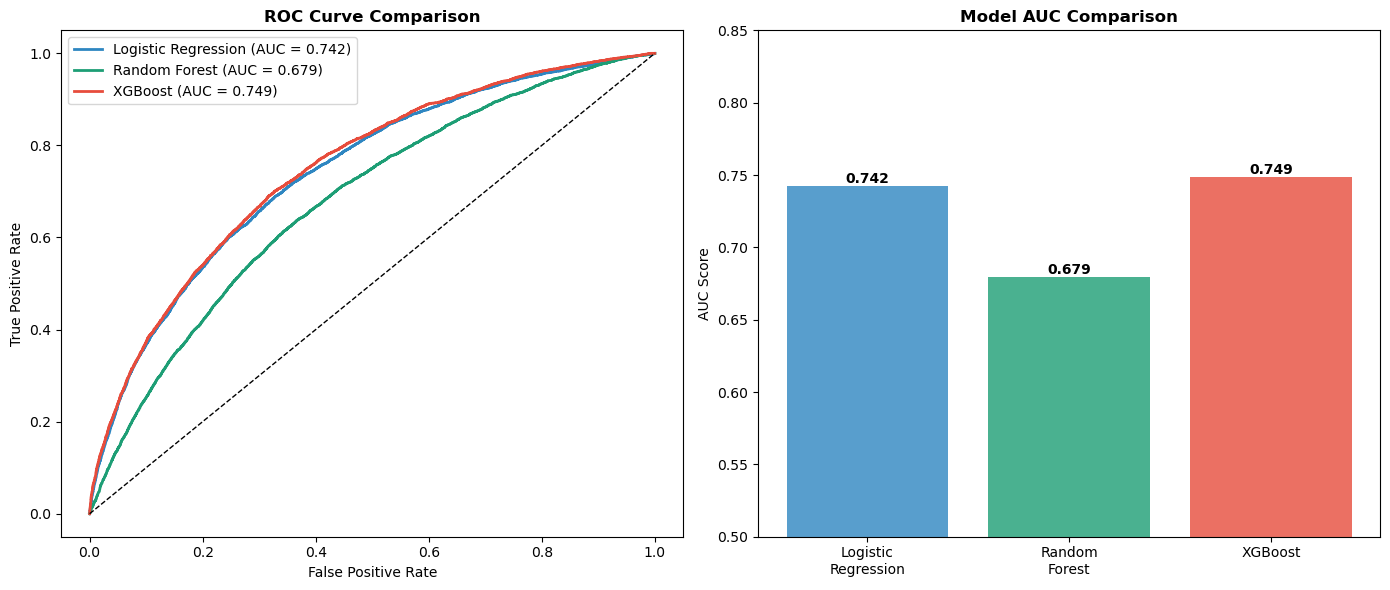

Chart 6 saved


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curves
models = {
    'Logistic Regression': lr_prob,
    'Random Forest': rf_prob,
    'XGBoost': xgb_prob
}
colors = ['#2E86C1', '#1D9E75', '#E74C3C']

for (name, prob), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    score = roc_auc_score(y_test, prob)
    ax1.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {score:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve Comparison', fontweight='bold')
ax1.legend()

# AUC Bar comparison
aucs = [lr_auc, rf_auc, xgb_auc]
names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
bars = ax2.bar(names, aucs, color=colors, alpha=0.8)
ax2.set_ylim(0.5, 0.85)
ax2.set_ylabel('AUC Score')
ax2.set_title('Model AUC Comparison', fontweight='bold')

for bar, auc_val in zip(bars, aucs):
    ax2.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + 0.002,
             f'{auc_val:.3f}', ha='center',
             fontweight='bold')

plt.tight_layout()
plt.savefig('../charts/06_model_comparison.png', dpi=150)
plt.show()
print("Chart 6 saved")

In [10]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save XGBoost as final model
joblib.dump(xgb_model, '../models/xgboost_credit_risk.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Models saved!")
print(f"\nFinal Model Comparison:")
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Random Forest AUC:       {rf_auc:.4f}")
print(f"XGBoost AUC:             {xgb_auc:.4f}")
print(f"\nBest model: XGBoost with AUC {xgb_auc:.4f}")

Models saved!

Final Model Comparison:
Logistic Regression AUC: 0.7422
Random Forest AUC:       0.6793
XGBoost AUC:             0.7488

Best model: XGBoost with AUC 0.7488
